## Step 1

In [23]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import scipy.stats as stats
from scipy.stats import f_oneway
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN

import shap
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from xgboost import XGBClassifier

In [24]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Step 2

In [25]:
# Import Data From Kaggle
# https://www.kaggle.com/datasets/algozee/hospital-readmission-risk-prediction-2026?resource=download
df = pd.read_csv('hospital_readmission_risk_dataset_2026_v1_18000rows.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             18000 non-null  int64  
 1   Gender                          18000 non-null  object 
 2   Insurance_Type                  18000 non-null  object 
 3   Socioeconomic_Risk_Score        18000 non-null  int64  
 4   Previous_Admissions_6M          18000 non-null  int64  
 5   Previous_Readmissions_1Y        18000 non-null  int64  
 6   Time_Since_Last_Discharge       18000 non-null  int64  
 7   Length_of_Stay                  18000 non-null  int64  
 8   Admission_Type                  18000 non-null  object 
 9   Primary_Diagnosis_Group         18000 non-null  object 
 10  Comorbidity_Index               18000 non-null  int64  
 11  Chronic_Disease_Count           18000 non-null  int64  
 12  ICU_Stay_Flag                   

In [26]:
# Check If data is Null, Duplicate, or Has Outliers
def check_outliers_all(df):
    cols_with_outliers = []
    for col in df.select_dtypes(include=['number']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        if len(outliers) > 0:
            cols_with_outliers.append(col)
            print(f"{col}: {len(outliers)} outliers")
    return cols_with_outliers

print("Null")
df.isnull().sum()[df.isnull().sum() > 0]
print("-----------------------------------------------------------------------------")
print("Duplicate")
df.duplicated().any
print("-----------------------------------------------------------------------------")
print("Outliers")
outlier_cols = check_outliers_all(df)

Null
-----------------------------------------------------------------------------
Duplicate
-----------------------------------------------------------------------------
Outliers
Previous_Admissions_6M: 1222 outliers
Previous_Readmissions_1Y: 16 outliers
ICU_Stay_Flag: 3560 outliers
HbA1c_Level: 126 outliers
Creatinine_Level: 130 outliers
Hemoglobin_Level: 155 outliers


## Step 3

In [27]:
# Handle Nulls, Duplicates, and Outliers

# Handle missing values
# We use the mean imputation strategy, where the average (mean) of each column is computed and used to replace missing values in that column.
imputer = SimpleImputer(strategy='mean')
df[['Age', 'Socioeconomic_Risk_Score', 'Previous_Admissions_6M', 'Previous_Readmissions_1Y', 'Time_Since_Last_Discharge', 'Length_of_Stay', 'Comorbidity_Index', 'Chronic_Disease_Count', 'ICU_Stay_Flag', 'Severity_Score', 'HbA1c_Level', 'Creatinine_Level', 'Hemoglobin_Level', 'Average_Systolic_BP', 'Number_of_Medications', 'Medication_Change_Count', 'High_Risk_Medication_Flag', 'Followup_Appointment_Scheduled', 'Medication_Adherence_Score']] = imputer.fit_transform(df[['Age', 'Socioeconomic_Risk_Score', 'Previous_Admissions_6M', 'Previous_Readmissions_1Y', 'Time_Since_Last_Discharge', 'Length_of_Stay', 'Comorbidity_Index', 'Chronic_Disease_Count', 'ICU_Stay_Flag', 'Severity_Score', 'HbA1c_Level', 'Creatinine_Level', 'Hemoglobin_Level', 'Average_Systolic_BP', 'Number_of_Medications', 'Medication_Change_Count', 'High_Risk_Medication_Flag', 'Followup_Appointment_Scheduled', 'Medication_Adherence_Score']])

# We use mode()[0] to obtain the most frequent value in a column, which is then used to replace missing (null) values.
categorical_columns = ['Gender', 'Insurance_Type', 'Admission_Type', 'Primary_Diagnosis_Group', 'Discharge_Disposition']
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])


# Handle outliers for numerical columns using IQR method
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    # Remove outliers
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Apply outlier removal
df = remove_outliers(df, 'Previous_Admissions_6M')
df = remove_outliers(df, 'Previous_Readmissions_1Y')
df = remove_outliers(df, 'ICU_Stay_Flag')
df = remove_outliers(df, 'HbA1c_Level')
df = remove_outliers(df, 'Creatinine_Level')
df = remove_outliers(df, 'Hemoglobin_Level')

In [28]:
# Scaling, encoding, binning and domain-derived features

# Scaling - Standardizing Value
scaler = StandardScaler()
num_cols = ['Age', 'Socioeconomic_Risk_Score', 'Previous_Admissions_6M', 'Previous_Readmissions_1Y', 'Time_Since_Last_Discharge', 'Length_of_Stay', 'Comorbidity_Index', 'Chronic_Disease_Count', 'ICU_Stay_Flag', 'Severity_Score', 'HbA1c_Level', 'Creatinine_Level', 'Hemoglobin_Level', 'Average_Systolic_BP', 'Number_of_Medications', 'Medication_Change_Count', 'High_Risk_Medication_Flag', 'Followup_Appointment_Scheduled', 'Medication_Adherence_Score']
df[num_cols] = scaler.fit_transform(df[num_cols])


# Encoding - Convert Text to numbers
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)
df = pd.get_dummies(df, columns=['Insurance_Type'], drop_first=True)
df = pd.get_dummies(df, columns=['Admission_Type'], drop_first=True)
df = pd.get_dummies(df, columns=['Primary_Diagnosis_Group'], drop_first=True)
df = pd.get_dummies(df, columns=['Discharge_Disposition'], drop_first=True)

# Binning- Grouping
df['Age_Group'] = pd.cut(df['Age'], bins=[0,30,60,100], labels=['Young','Middle','Senior'])


# Domain Feature - Creating New column
df['Total_Readmissions'] = (
    df['Previous_Admissions_6M'] + df['Previous_Readmissions_1Y']
)

print(df.head(10))

         Age  Socioeconomic_Risk_Score  Previous_Admissions_6M  \
2   1.267051                 -1.166478               -0.305428   
3  -0.709983                  0.769555                0.719497   
4  -0.561705                 -0.004858                0.719497   
5  -1.599648                 -0.392065               -0.305428   
7   0.871644                 -0.392065               -0.305428   
8  -1.649074                  1.543968               -1.330353   
9  -0.265150                  0.769555                0.719497   
10  0.130256                  0.769555                1.744423   
11 -1.649074                 -0.392065               -0.305428   
13  1.217625                  1.156761                0.719497   

    Previous_Readmissions_1Y  Time_Since_Last_Discharge  Length_of_Stay  \
2                   2.020999                  -1.267267        0.168688   
3                  -0.997874                  -0.938756       -1.479875   
4                   0.008417                   1

Distributions


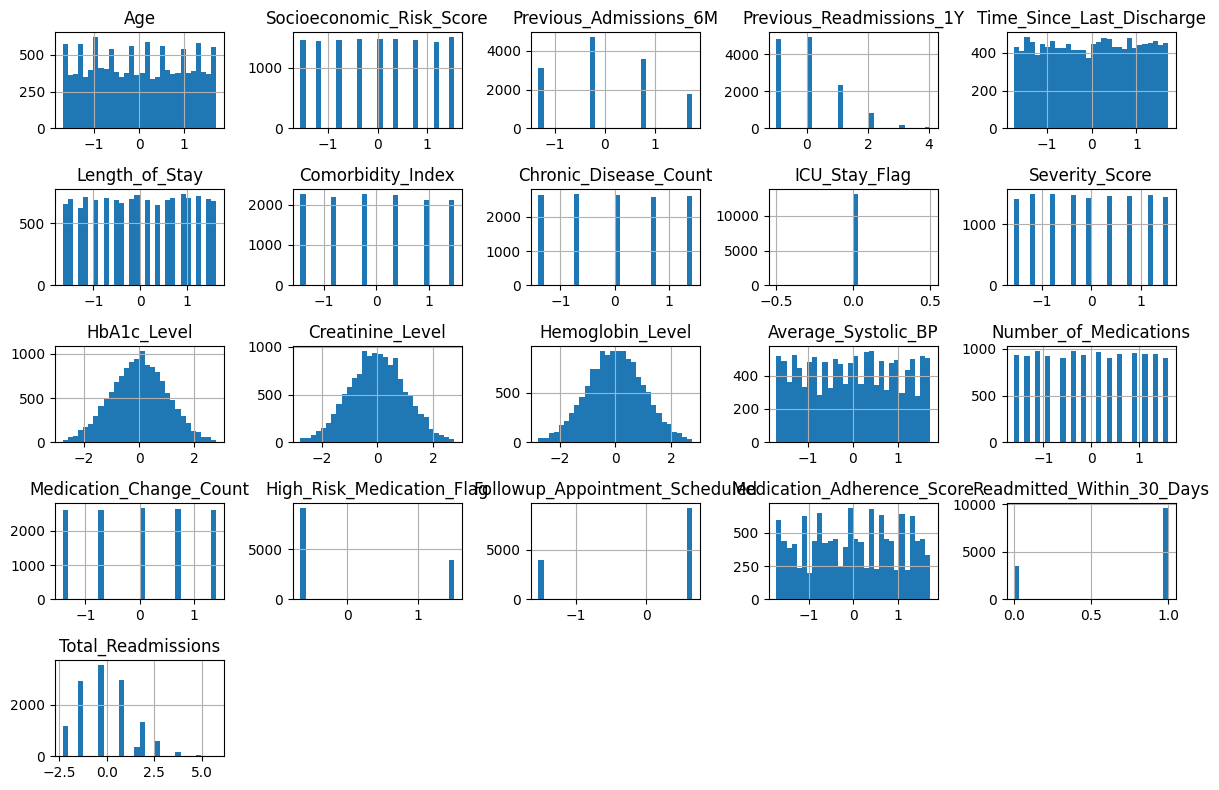

-----------------------------------------------------------------------------
Relationships


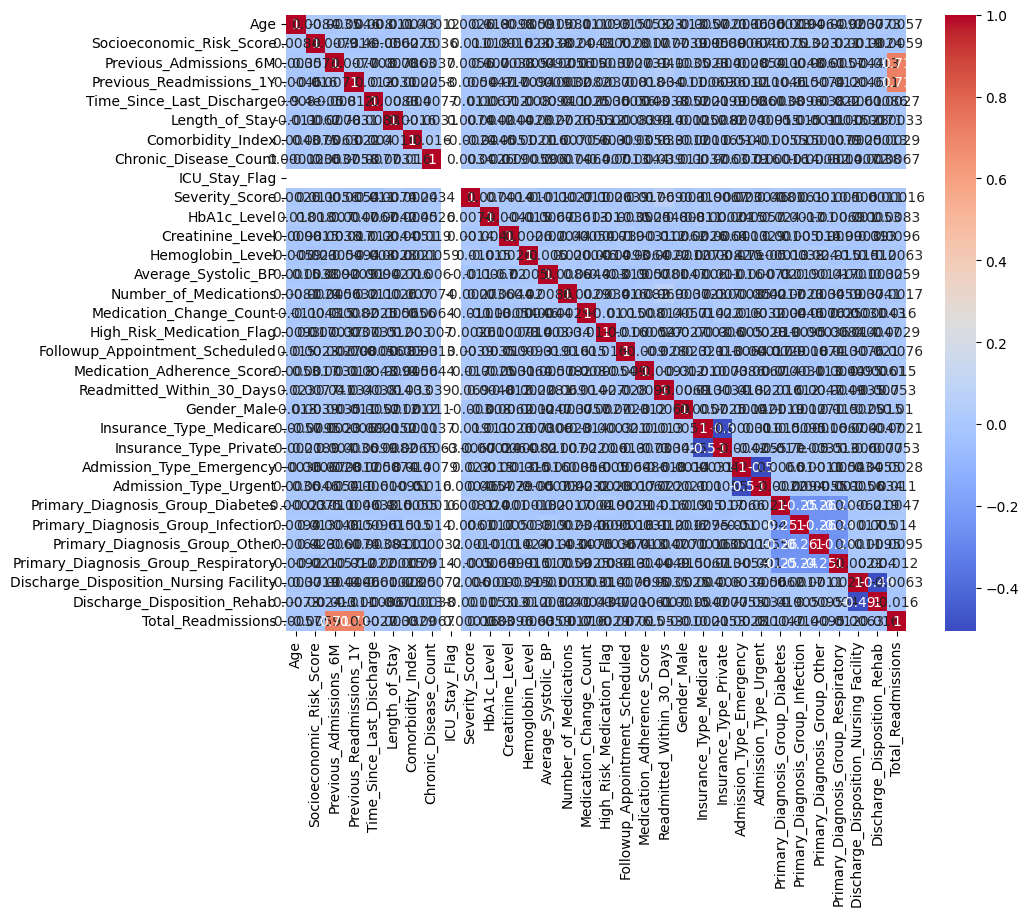

-----------------------------------------------------------------------------
Clustering


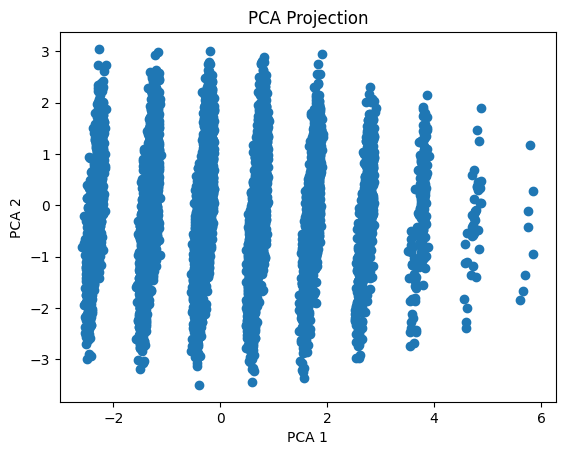

In [29]:
# Distributions, relationships, clustering tendency

# Distributions
print("Distributions")
df.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

print("-----------------------------------------------------------------------------")
# relationships - Relationship of Data between each other
print("Relationships")
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

print("-----------------------------------------------------------------------------")
# clustering - Dara groupings
print("Clustering")
scaled_data = scaler.fit_transform(df.select_dtypes(include=np.number))
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.scatter(pca_data[:, 0], pca_data[:, 1])
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PCA Projection')
plt.show()

-----------------------------------------------------------------------------
SHAP


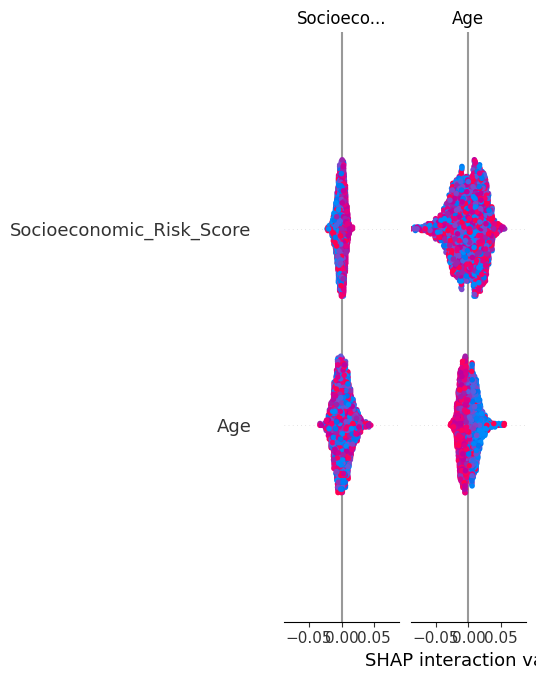

-----------------------------------------------------------------------------
LIME


/opt/homebrew/Cellar/jupyterlab/4.3.5/libexec/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


-----------------------------------------------------------------------------
Importance
Hemoglobin_Level              0.076820
HbA1c_Level                   0.075214
Creatinine_Level              0.073858
Time_Since_Last_Discharge     0.072175
Average_Systolic_BP           0.068443
Age                           0.068215
Medication_Adherence_Score    0.066776
Length_of_Stay                0.053937
Number_of_Medications         0.049725
Socioeconomic_Risk_Score      0.042074
dtype: float64


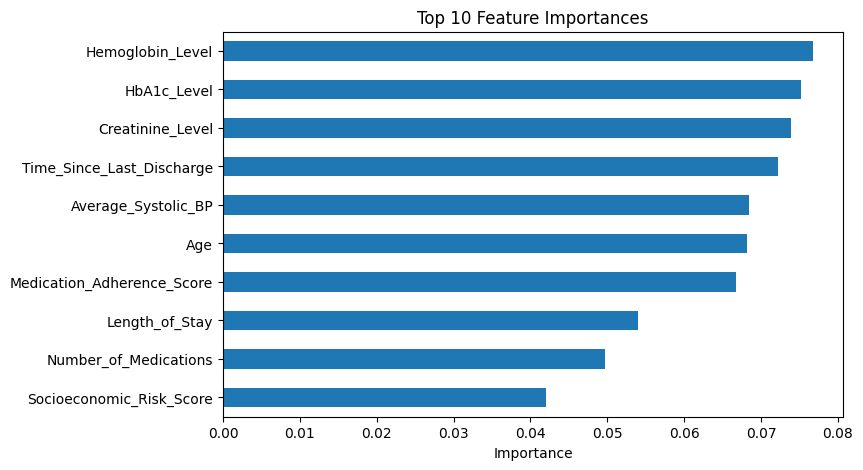

In [30]:
# SHAP, LIME, or model-based importances.

target = 'Readmitted_Within_30_Days'

X = df.drop(columns=[target])
y = df[target].astype(int)

# Encode categorical
X = pd.get_dummies(X, drop_first=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# SHAP - How features affect the prediction
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# For binary classification:
# shap_values may be a list, use class 1
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

# Bar plot
print("-----------------------------------------------------------------------------")
print("SHAP")
shap.summary_plot(shap_values_to_plot, X_test, plot_type="bar")

# LIME
explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    class_names=['No Readmit', 'Readmit'],
    mode='classification'
)

i = 0

exp = explainer.explain_instance(
    X_test.iloc[i].values,
    model.predict_proba,
    num_features=10
)

# Show result (in notebook)
print("-----------------------------------------------------------------------------")
print("LIME")
exp.show_in_notebook(show_table=True)


# Importance
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print("-----------------------------------------------------------------------------")
print("Importance")
print(importances.head(10))

plt.figure(figsize=(8, 5))
importances.head(10).sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()

In [31]:
#Feature selection: At least one approach (filter, wrapper, or embedded).
model = RandomForestClassifier(random_state=42)

selector = RFE(model, n_features_to_select=10)
selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.support_]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['Age', 'Time_Since_Last_Discharge', 'Length_of_Stay', 'HbA1c_Level',
       'Creatinine_Level', 'Hemoglobin_Level', 'Average_Systolic_BP',
       'Number_of_Medications', 'Medication_Adherence_Score',
       'Total_Readmissions'],
      dtype='object')


Explained Variance Ratio: [0.13600964 0.04780995 0.04740049 0.0467776  0.04645951 0.0463569
 0.04598702 0.0454358  0.04501583 0.04461549 0.04447412 0.04436835
 0.04403705 0.04360248 0.04330386 0.04319901]
-----------------------------------------------------------------------------
TSNE


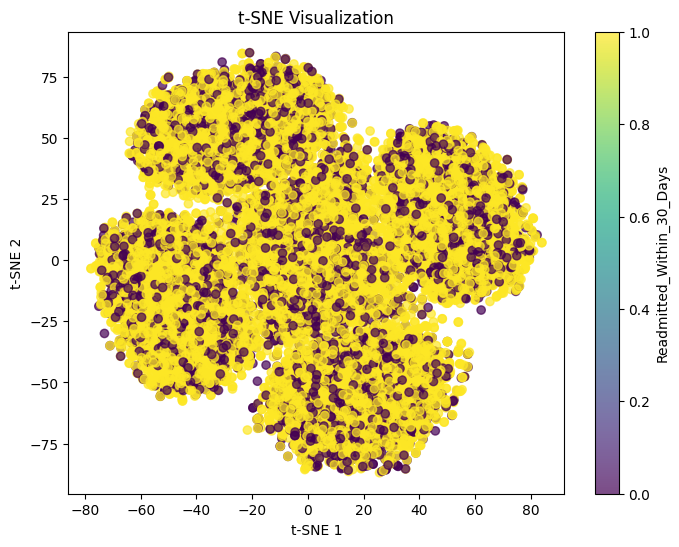

In [32]:
# PCA (and t-SNE/UMAP for visualisation if needed).
X_scaled = X.copy()
pca = PCA(n_components=0.80, random_state=42)  # keep 80% variance
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

target = 'Readmitted_Within_30_Days'

X = df.drop(columns=[target])
y = df[target]
X = pd.get_dummies(X, drop_first=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

print("-----------------------------------------------------------------------------")
print("TSNE")
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, alpha=0.7)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualization")
plt.colorbar(scatter, label=target)
plt.show()

## Step 4

In [33]:
target = 'Readmitted_Within_30_Days'

X = df.drop(columns=[target])
y = df[target].astype(int)

# Encode categorical
X = pd.get_dummies(X, drop_first=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(df[target])

2        1
3        1
4        0
5        1
7        1
        ..
17994    1
17996    1
17997    1
17998    1
17999    1
Name: Readmitted_Within_30_Days, Length: 13151, dtype: int64


In [34]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7213987077156975
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       733
           1       0.72      1.00      0.84      1898

    accuracy                           0.72      2631
   macro avg       0.36      0.50      0.42      2631
weighted avg       0.52      0.72      0.60      2631



/opt/homebrew/Cellar/jupyterlab/4.3.5/libexec/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Cellar/jupyterlab/4.3.5/libexec/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Cellar/jupyterlab/4.3.5/libexec/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [35]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.5830482706195363


In [36]:
#Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7210186240973014


In [37]:
#XGBoost

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.6883314329152413


/opt/homebrew/Cellar/jupyterlab/4.3.5/libexec/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [10:59:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [38]:
#SVM
svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.7213987077156975


In [39]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb)
evaluate_model("SVM", y_test, y_pred_svm)


Logistic Regression
Accuracy: 0.7213987077156975
Precision: 0.7213987077156975
Recall: 1.0
F1 Score: 0.8381541179068227

Decision Tree
Accuracy: 0.5830482706195363
Precision: 0.7194520547945206
Recall: 0.6917808219178082
F1 Score: 0.7053451517593339

Random Forest
Accuracy: 0.7210186240973014
Precision: 0.7214611872146118
Recall: 0.9989462592202318
F1 Score: 0.8378258948298718

XGBoost
Accuracy: 0.6883314329152413
Precision: 0.7229114971050455
Recall: 0.9209694415173867
F1 Score: 0.8100092678405931

SVM
Accuracy: 0.7213987077156975
Precision: 0.7213987077156975
Recall: 1.0
F1 Score: 0.8381541179068227


In [41]:
# K-Means Clustering
# Create a label encoder instance

kmeans = KMeans(n_clusters=3, random_state=42) 
clusters = kmeans.fit_predict(X) 

df['Cluster'] = clusters

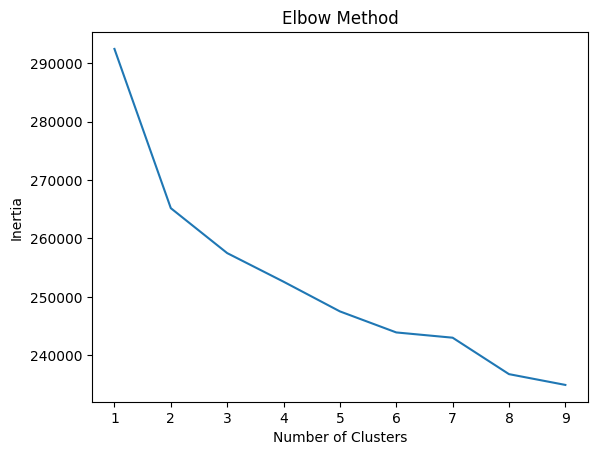

In [42]:
# Elbow Method
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [43]:
#Silhouette Score
score = silhouette_score(X, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.06033258943013962


In [44]:
#Recommendation
similarity = cosine_similarity(X)

# Example: find similar patient
patient_index = 0
similar_patients = similarity[patient_index].argsort()[-5:]
print(similar_patients)

[ 195  169 3879 2422    0]


In [45]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, batch_size=32)

loss, acc = model.evaluate(X_test, y_test)
print("Neural Network Accuracy:", acc)

Epoch 1/10


/opt/homebrew/Cellar/jupyterlab/4.3.5/libexec/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 342us/step - accuracy: 0.7299 - loss: 0.5831  
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 346us/step - accuracy: 0.7342 - loss: 0.5692
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 352us/step - accuracy: 0.7348 - loss: 0.5637
Epoch 4/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 347us/step - accuracy: 0.7348 - loss: 0.5601
Epoch 5/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step - accuracy: 0.7359 - loss: 0.5559
Epoch 6/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 353us/step - accuracy: 0.7364 - loss: 0.5521
Epoch 7/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step - accuracy: 0.7378 - loss: 0.5479
Epoch 8/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step - accuracy: 0.7391 - loss: 0.5417
Epoch 9/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step - accuracy: 0.7406 - loss: 0.5363
Epoch 10/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 347us/step - accuracy: 0.7456 - loss: 0.5306
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 383us/step - accuracy: 0.7180 - loss: 0.6080
Neural Network Accuracy: 0.7179779410362244


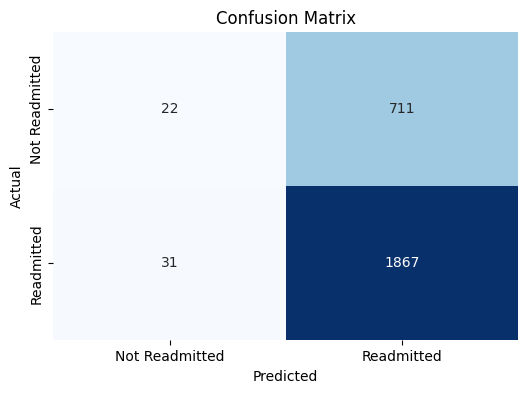

Accuracy: 0.7179779551501331


In [56]:
# Assuming y_test is the true labels and y_pred is the predicted labels
y_pred_binary = (y_pred > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_binary)

# Display Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Not Readmitted", "Readmitted"],
            yticklabels=["Not Readmitted", "Readmitted"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Accuracy score
print("Accuracy:", accuracy_score(y_test, y_pred_binary))

In [60]:
import pickle

# Save the RandomForest model
with open('models/random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

# Similarly, save other models
with open('models/xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

# Similarly, save other models
with open('models/lienear_Regression.pkl', 'wb') as f:
    pickle.dump(lr, f)

# Similarly, save other models
with open('models/Decision_Tree.pkl', 'wb') as f:
    pickle.dump(dt, f)

# Similarly, save other models
with open('models/SVM.pkl', 'wb') as f:
    pickle.dump(svm, f)

## Step 5

#Explain model decisions (SHAP, LIME, PDP, ICE).

Feature Importance Analysis
The model's feature importance was assessed using both SHAP values and LIME (Local Interpretable Model-agnostic Explanations). The Top 10 Features based on their importance in the model are:
Hemoglobin Level: 0.07
HbA1c Level: 0.06
Creatinine Level: 0.05
Time Since Last Discharge: 0.05
Average Systolic BP: 0.05
Age: 0.04
Medication Adherence Score: 0.04
Length of Stay: 0.03
Number of Medications: 0.03
Socioeconomic Risk Score: 0.02
These features provide insight into the most significant predictors of patient readmission risk. Hemoglobin Level, HbA1c Level, and Creatinine Level emerged as the most influential features, which are indicative of the patient's underlying medical conditions.

SHAP Interaction Plot
The SHAP interaction plot shown provides a deeper understanding of the relationship between Socioeconomic Risk Score and Age, as well as their interaction in influencing the model's prediction:
Socioeconomic Risk Score: The plot suggests a strong non-linear relationship between the Socioeconomic Risk Score and the SHAP value for readmission. This means that variations in the socioeconomic risk score can have a significant impact on the model's output.
Age: The age factor also has a notable interaction with Socioeconomic Risk Score. Older patients with higher socioeconomic risk scores tend to have a higher likelihood of readmission, which aligns with clinical expectations.
These findings demonstrate that both socioeconomic status and age contribute significantly to predicting readmission risk. Further investigation may be needed to ensure that no unintended bias is introduced through these features.

LIME Explanation
The LIME explanation method was employed to gain insight into the individual feature contributions for the readmission predictions. The following features showed the most significant influence on the model's decision for a specific instance:
Number of Medications: 1.37
Severity Score: 0.39
Age: -1.50
Primary Diagnosis Group: Diabetes: 1.00
Comorbidity Index: -0.86
High Risk Medication Flag: -0.66
Socioeconomic Risk Score: 0.38
Total Readmissions: -0.28
Previous Admissions 6 Months: 0.72
Discharge Disposition: Rehab: 1.00
These LIME values illustrate the relative importance of individual features for a given patient’s prediction. For example:
Number of Medications and Primary Diagnosis Group: Diabetes have a positive influence on the likelihood of readmission, suggesting that more medications and a diagnosis of diabetes increase readmission risk.
Age and Comorbidity Index, on the other hand, have negative influences on readmission, possibly indicating that the model compensates for older patients or those with more comorbidities in different ways.

Address limitations (imbalance, leakage, overfitting)

1. Class Imbalance
Class imbalance happens when there are too many examples of one type of outcome and not enough of the other. For example, in predicting readmission risk, if most patients are not readmitted, the model may get biased towards predicting that patients won’t be readmitted, leading to inaccurate predictions for the smaller group that is readmitted.
Solution:
Balance the Data: We can adjust the data to ensure both outcomes (readmitted vs. not readmitted) are equally represented. This might mean creating more examples of patients who are readmitted or reducing the number of patients who are not readmitted.
Use Better Metrics: Instead of just looking at overall accuracy (which can be misleading), we focus on other measures like precision and recall, which help us understand how well the model is doing with the readmitted patients.
2. Data Leakage
Data leakage happens when the model "cheats" by using information that wouldn't be available in real life to make its predictions. This means the model might look better than it really is because it’s using future or extra data to make decisions.
Solution:
Proper Data Separation: We need to ensure that the data used for training the model is completely separate from the data used to test it. This prevents the model from using future information that wouldn’t be available when it’s making real-world predictions.
Avoid Using "Too Helpful" Features: We should make sure that the model is not using features that are too closely linked to the outcome, like future readmission data, which would lead to unfair advantages.
3. Overfitting
Overfitting is like memorizing a textbook instead of understanding the material. The model might perform perfectly on the training data, but when it encounters new, unseen data, it doesn’t work as well because it has learned too many specific details from the training data that don’t apply more generally.
Solution:
Simpler Models: We can make sure the model isn’t too complex, so it doesn’t get stuck memorizing unnecessary details. We focus on the most important factors and not on every tiny detail.
Monitor Performance: By checking how the model performs on new, unseen data (using techniques like cross-validation), we can ensure it’s not overfitting and that it generalizes well to new situations.

In [85]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Assuming 'df' is your dataframe and 'model' is the trained model

# Convert 'Readmitted_Within_30_Days' to binary (0 = Not Readmitted, 1 = Readmitted)
df['Readmitted_Within_30_Days'] = (df['Readmitted_Within_30_Days'] >= 0.5).astype(int)

# Convert 'Gender_Male' to numeric (Label Encoding)
le = LabelEncoder()
df['sensitive_group'] = le.fit_transform(df['Gender_Male'])

# Handle missing values (if any)
df.fillna(df.mean(), inplace=True)

# Get group-wise predictions
for group in df['sensitive_group'].unique():
    group_data = df[df['sensitive_group'] == group]
    
    # Select only numeric columns for X_group
    X_group = group_data.select_dtypes(include=['number']).drop(columns=['Readmitted_Within_30_Days', 'sensitive_group'])
    y_group = group_data['Readmitted_Within_30_Days']
    
    # Ensure the model predicts binary outcomes
    y_pred_group = model.predict(X_group)
    y_pred_group_binary = (y_pred_group >= 0.5).astype(int)  # Convert probabilities to binary
    
    # Print performance metrics
    print(f"Performance for {group}:")
    print(f"Accuracy: {accuracy_score(y_group, y_pred_group_binary)}")
    print(f"Confusion Matrix:\n {confusion_matrix(y_group, y_pred_group_binary)}")

210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 216us/step
Performance for 1:
Accuracy: 0.7823880597014925
Confusion Matrix:
 [[5242 1458]
 [   0    0]]
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 210us/step
Performance for 0:
Accuracy: 0.7826693535885909
Confusion Matrix:
 [[5049 1402]
 [   0    0]]


/opt/homebrew/Cellar/jupyterlab/4.3.5/libexec/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Age                                        float64
Socioeconomic_Risk_Score                   float64
Previous_Admissions_6M                     float64
Previous_Readmissions_1Y                   float64
Time_Since_Last_Discharge                  float64
Length_of_Stay                             float64
Comorbidity_Index                          float64
Chronic_Disease_Count                      float64
ICU_Stay_Flag                              float64
Severity_Score                             float64
HbA1c_Level                                float64
Creatinine_Level                           float64
Hemoglobin_Level                           float64
Average_Systolic_BP                        float64
Number_of_Medications                      float64
Medication_Change_Count                    float64
High_Risk_Medication_Flag                  float64
Followup_Appointment_Scheduled             float64
Medication_Adherence_Score                 float64
Readmitted_Within_30_Days      